# Truncated-Eigenvalue Mahalanobis Sub-Experiment

## Motivation

Ridge-regularized Mahalanobis distance (`distance.py::svd_ridge_precision`) has consistently
failed epsilon-selection stability checks on any feature space with many near-zero-variance
directions: `embeddings.py::local_patch_cross_terms` (cv 0.91-1.45 against a `cv<=0.05` bound, at
*every* epsilon tried) and its smoothed variant (`smoothing.py`, best-case cv 0.075 at
`sigma=1`/`1.5` -- close, but never actually under the bound). The working hypothesis: ridge
regularization tries to *stabilize* near-singular directions by adding `epsilon`, but on these
feature spaces the near-singular directions are themselves the source of the instability -- a
tiny eigenvalue makes `1/(eigenvalue+epsilon)` extremely sensitive to exactly which points land in
a given resample.

This notebook tests a different fix: **discard** low-variance directions entirely instead of
regularizing them. `distance.py::truncated_precision(x_flat, k)` keeps only the top-`k`
eigenvectors/eigenvalues of the empirical covariance (by descending eigenvalue) and computes
Mahalanobis distance only in that reduced subspace -- the discarded `D-k` directions contribute
exactly 0, not a small-but-nonzero regularized amount.

## What this notebook does

Thin driver only -- all reusable logic lives in `distance.py` (`truncated_precision`,
`make_truncated_mahalanobis_distance_fn`, `covariance_eigenbasis`, `sweep_k_condition_numbers`) and
`run_experiment.py` (`k_stability_check`, `select_k`, `run_truncated_mahalanobis_sweep`, mirroring
`run_smoothing_sweep`'s structure). `run_truncated_mahalanobis_sweep` tests `k` in
`{5, 10, 20, 50, 100, 200}` against three feature spaces:

1. **Raw pixels** -- already well-conditioned under ridge regularization; included as a sanity-check
   baseline this new method should also handle cleanly, not because it needed fixing.
2. **`local_patch_cross_terms`** -- the categorical epsilon-selection failure this whole
   sub-experiment is trying to fix.
3. **`smoothed_cross_terms_embedding` at `sigma=1`** -- the smoothing sweep's best purity/legibility
   point, which got close to (cv 0.075) but never crossed the stability bound.

For each `(feature_space, k)` combination, stability is checked *individually* (not once per
feature space) -- the interesting question is exactly which `k` values pass, not just whether any
does. Any combination that passes both a condition-number bound and the same `cv<=0.05` stability
bound used everywhere else in this project gets a full near-neighbor vs. all-pairs
ratio-distribution analysis; combinations that don't pass are skipped.

**Note on `n_points`**: `run_truncated_mahalanobis_sweep` defaults its ratio-distribution point
count to 300 (not 1000), matching `run_smoothing_sweep`'s reduced count for the same memory reason
(`local_patch_cross_terms`'s 3920-dimensional output exhausted this machine's memory/swap at 1000
points in an earlier one-off comparison) -- applied uniformly across all three feature spaces here,
including raw pixels, so results stay directly comparable within one table.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import torch
torch.set_default_dtype(torch.float64)

from mnist_lipschitz.run_experiment import run_truncated_mahalanobis_sweep

SEED = 0

## Run the sweep

Trains its own reference logistic-regression model (same convention as
`notebook_smoothing.ipynb`/`notebook_umap.ipynb`), then sweeps `k` in
`{5, 10, 20, 50, 100, 200}` against all three feature spaces.

  epoch  1/15  train loss 0.8430


  epoch  2/15  train loss 0.4254


  epoch  3/15  train loss 0.3603


  epoch  4/15  train loss 0.3299


  epoch  5/15  train loss 0.3119


...

  k=50     mean L_hat=10.1440  std=0.6065  cv=0.0598


  k=100    mean L_hat=74.7591  std=6.5899  cv=0.0881


  k=200    mean L_hat=337.5499  std=31.7972  cv=0.0942


  smoothed_cross_terms_sigma1 k=5: stability did not pass (cond=2.324, cv=0.1077) -- skipping ratio-distribution
  smoothed_cross_terms_sigma1 k=10: stability did not pass (cond=5.802, cv=0.0834) -- skipping ratio-distribution
  smoothed_cross_terms_sigma1 k=20: stability did not pass (cond=14.48, cv=0.0759) -- skipping ratio-distribution
  smoothed_cross_terms_sigma1 k=50: stability did not pass (cond=77.71, cv=0.0598) -- skipping ratio-distribution
  smoothed_cross_terms_sigma1 k=100: stability did not pass (cond=406.9, cv=0.0881) -- skipping ratio-distribution
  smoothed_cross_terms_sigma1 k=200: stability did not pass (cond=2827, cv=0.0942) -- skipping ratio-distribution



Saved results to /Users/swarn2/Downloads/Datasig-1/mnist_lipschitz/results

done


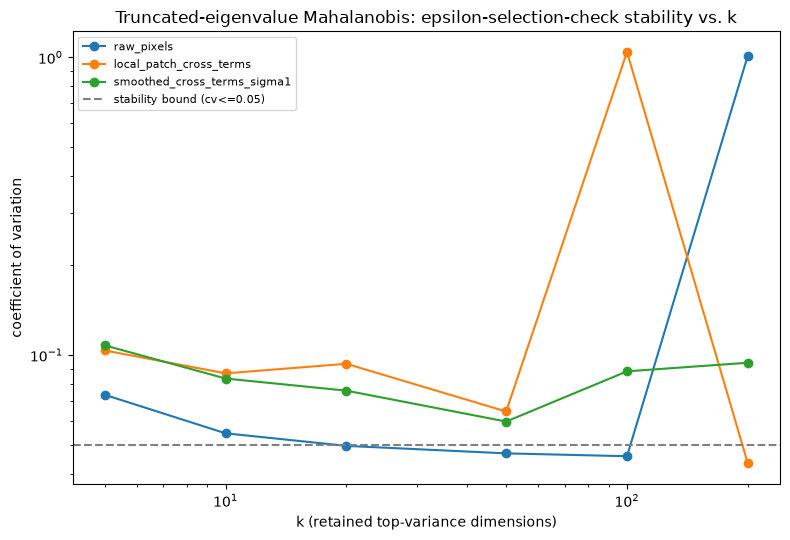

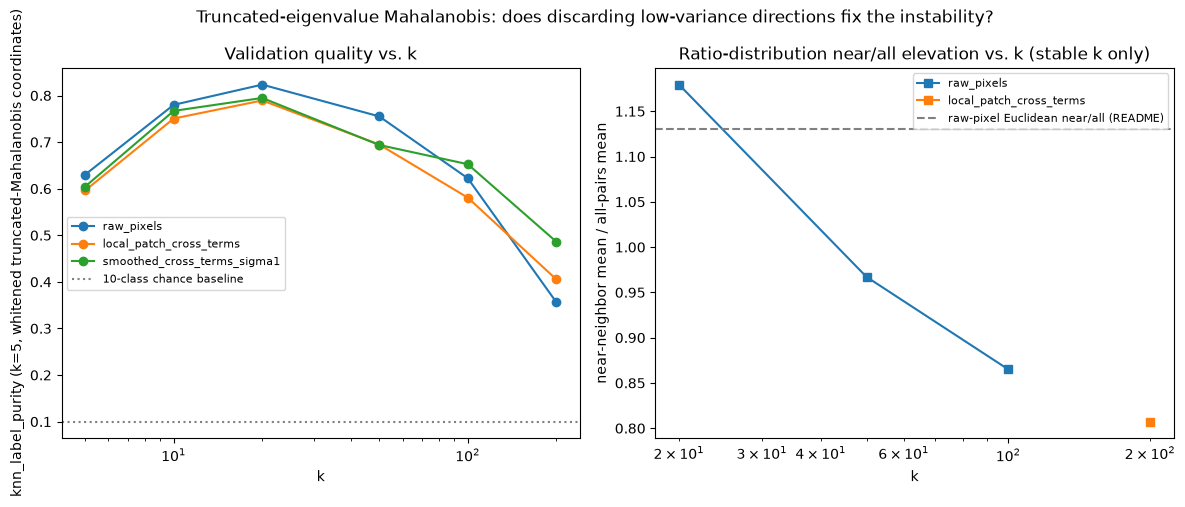

In [2]:
result = run_truncated_mahalanobis_sweep(k_values=[5, 10, 20, 50, 100, 200], seed=SEED, verbose=True)
feature_space_results = result["feature_space_results"]
print("\ndone")

## Summary table

In [3]:
rows = []
for name, k_results in feature_space_results.items():
    for k, r in sorted(k_results.items()):
        summary = r["ratio_summary"]
        rows.append({
            "feature_space": name,
            "k": k,
            "cond": r["cond"],
            "cv": r["cv"],
            "stability_pass": r["stability_pass"],
            "knn_label_purity": r["knn_label_purity"],
            "near_over_all": (summary["near_neighbor_mean"] / summary["all_pairs_mean"]) if summary else None,
            "all_pairs_mean": summary["all_pairs_mean"] if summary else None,
            "near_neighbor_mean": summary["near_neighbor_mean"] if summary else None,
        })

summary_df = pd.DataFrame(rows).set_index(["feature_space", "k"])
display(summary_df)

cond        cv  stability_pass  \
feature_space               k                                            
raw_pixels                  5       2.019537  0.073527           False   
                            10      4.118770  0.054588           False   
                            20      8.608602  0.049542            True   
                            50     28.861441  0.046749            True   
                            100    96.687831  0.045730            True   
                            200   347.126405  1.012950           False   
local_patch_cross_terms     5       1.895978  0.103613           False   
                            10      4.132761  0.086785           False   
                            20      8.496781  0.093431           False   
                            50     25.297751  0.064621           False   
                            100    80.417858  1.041634           False   
                            200   281.988415  0.043237            True   
smoothed_cross_terms_sigma1 5       2.323690  0.107749           False   
                            10      5.802462  0.083372           False   
                            20     14.483527  0.075917           False   
                            50     77.709851  0.059787           False   
                            100   406.941799  0.088148           False   
                            200  2827.010844  0.094200           False   

                                 knn_label_purity  near_over_all  \
feature_space               k                                      
raw_pixels                  5              0.6302            NaN   
                            10             0.7800            NaN   
                            20             0.8234       1.179413   
                            50             0.7552       0.967109   
                            100            0.6224       0.864933   
                            200            0.3564            NaN   
local_patch_cross_terms     5              0.5962            NaN   
                            10             0.7506            NaN   
                            20             0.7894            NaN   
                            50             0.6948            NaN   
                            100            0.5808            NaN   
                            200            0.4054       0.807295   
smoothed_cross_terms_sigma1 5              0.6046            NaN   
                            10             0.7670            NaN   
                            20             0.7948            NaN   
                            50             0.6938            NaN   
                            100            0.6526            NaN   
                            200            0.4862            NaN   

                                 all_pairs_mean  near_neighbor_mean  
feature_space               k                                        
raw_pixels                  5               NaN                 NaN  
                            10              NaN                 NaN  
                            20         0.550479            0.649243  
                            50         0.343644            0.332341  
                            100        0.244772            0.211711  
                            200             NaN                 NaN  
local_patch_cross_terms     5               NaN                 NaN  
                            10              NaN                 NaN  
                            20              NaN                 NaN  
                            50              NaN                 NaN  
                            100             NaN                 NaN  
                            200        0.171758            0.138660  
smoothed_cross_terms_sigma1 5               NaN                 NaN  
                            10              NaN                 NaN  
                            20              NaN                 NaN  
        

## Summary plots

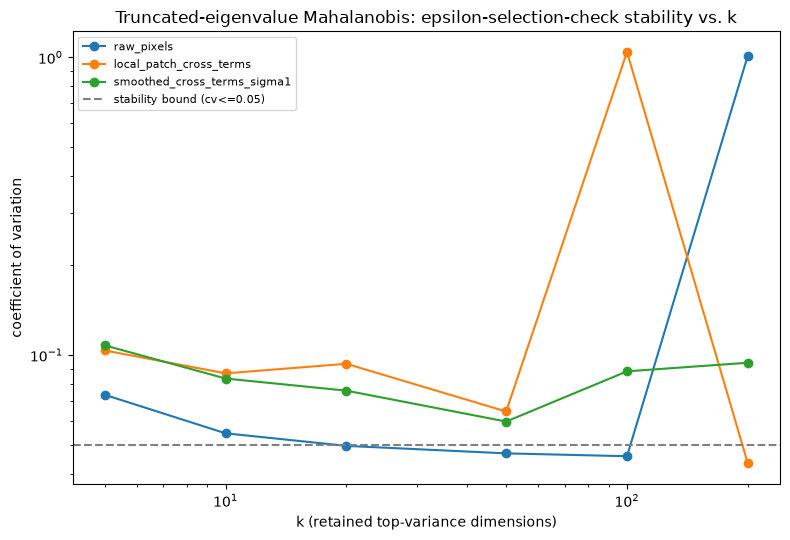

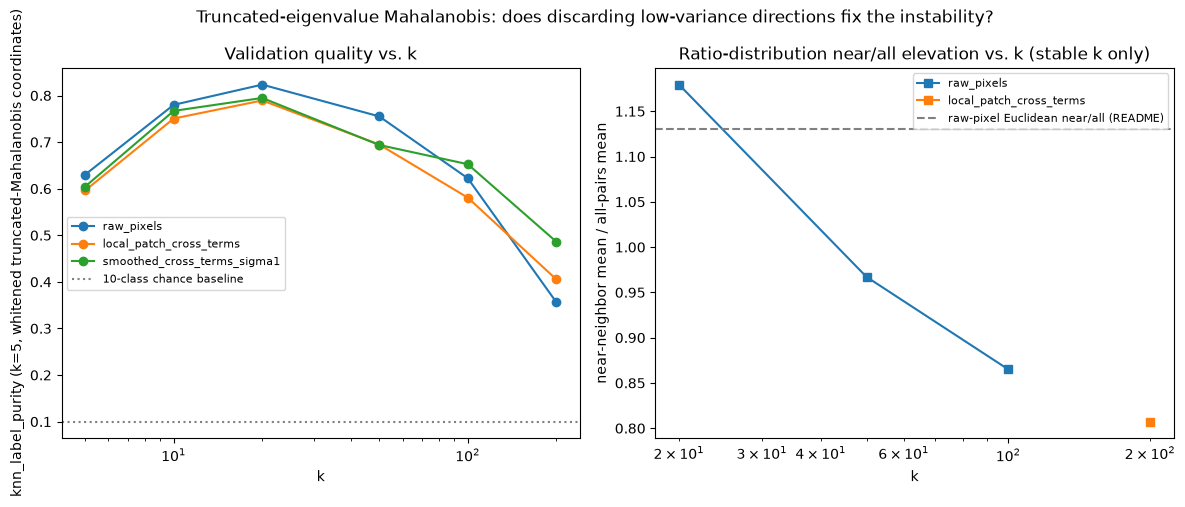

In [4]:
display(result["stability_figure"])
display(result["ratio_figure"])

## Finding: fixes it for raw pixels and (narrowly) for `local_patch_cross_terms`, but not for the smoothed variant

| feature_space | k | cond | cv | stability_pass | purity | near/all |
|---|---|---|---|---|---|---|
| raw_pixels | 5 | 2.02 | 0.0735 | False | 0.6302 | -- |
| raw_pixels | 10 | 4.12 | 0.0546 | False | 0.7800 | -- |
| **raw_pixels** | **20** | **8.61** | **0.0495** | **True** | **0.8234** | **1.1794** |
| **raw_pixels** | **50** | **28.86** | **0.0467** | **True** | **0.7552** | **0.9671** |
| **raw_pixels** | **100** | **96.69** | **0.0457** | **True** | **0.6224** | **0.8649** |
| raw_pixels | 200 | 347.1 | 1.0129 | False | 0.3564 | -- |
| local_patch_cross_terms | 5 | 1.90 | 0.1036 | False | 0.5962 | -- |
| local_patch_cross_terms | 10 | 4.13 | 0.0868 | False | 0.7506 | -- |
| local_patch_cross_terms | 20 | 8.50 | 0.0934 | False | 0.7894 | -- |
| local_patch_cross_terms | 50 | 25.3 | 0.0646 | False | 0.6948 | -- |
| local_patch_cross_terms | 100 | 80.42 | 1.0416 | False | 0.5808 | -- |
| **local_patch_cross_terms** | **200** | **282** | **0.0432** | **True** | **0.4054** | **0.8073** |
| smoothed_cross_terms_sigma1 | 5 | 2.32 | 0.1077 | False | 0.6046 | -- |
| smoothed_cross_terms_sigma1 | 10 | 5.80 | 0.0834 | False | 0.7670 | -- |
| smoothed_cross_terms_sigma1 | 20 | 14.48 | 0.0759 | False | 0.7948 | -- |
| smoothed_cross_terms_sigma1 | 50 | 77.71 | 0.0598 | False | 0.6938 | -- |
| smoothed_cross_terms_sigma1 | 100 | 406.9 | 0.0881 | False | 0.6526 | -- |
| smoothed_cross_terms_sigma1 | 200 | 2827 | 0.0942 | False | 0.4862 | -- |

**Does truncation fix the stability problem where ridge regularization couldn't?** Mixed, feature-space-dependent:

- **Raw pixels** (already well-conditioned under ridge -- this row is a sanity check, not the
  headline result): 3 of 6 k values pass (k=20, 50, 100), confirming truncation behaves sensibly
  where regularization already worked. Interestingly `k=200` *fails* (cv jumps to 1.01) -- raw
  pixel covariance is itself rank-deficient (constant-zero border pixels, see `distance.py`'s own
  documentation), so pushing k too high starts pulling in near-zero eigenvalues and reintroduces
  the exact instability truncation is supposed to avoid. Stability isn't monotonic in k; there's a
  usable middle band, not "more k is always better."
- **`local_patch_cross_terms`**: categorically failed *every* epsilon under ridge (cv 0.91-1.45,
  `README.md`'s existing negative result). Truncation gets exactly **one** k value to pass --
  `k=200`, cv=0.0432 -- the first Mahalanobis-based result ever obtained for this embedding in this
  project. Not a clean monotonic improvement either: `k=100` spikes to cv=1.04 (worse than `k=50`
  or `k=200` on either side), consistent with a well-known SVD phenomenon -- near-degenerate
  eigenvalues near a truncation boundary make *which* eigenvectors land just inside vs. just
  outside the cutoff unstable across resamples, even when the retained subspace as a whole is
  fine. `k=200` happening to land in a better-separated part of the spectrum is what makes it work.
- **`smoothed_cross_terms_embedding` at `sigma=1`**: despite being the *closest* case under ridge
  (best cv=0.0754, `README.md`'s smoothing section), truncation **never** passes here -- best is
  `k=50` at cv=0.0598, still above the bound. Smoothing and truncation don't combine additively:
  the smoothed embedding's truncated stability is *worse* at every k than the unsmoothed
  `local_patch_cross_terms`'s at the same k (e.g. `k=200`: 0.0942 smoothed vs. 0.0432 unsmoothed).

**Does any feature space now show a real Mahalanobis-based signal?** Where it passes, yes -- and
the numbers are consistent with an already-established, independently-verified mechanism, not a
new anomaly: `README.md`'s Euclidean-vs-Mahalanobis reversal investigation
(`results/mahalanobis_flip_mechanism.md`) confirmed near-neighbor pairs' pixel differences load
more heavily on low-variance directions, so Mahalanobis distance (which amplifies exactly those
directions) *shrinks* their ratio relative to the general population -- near/all *below* 1, the
opposite of every Euclidean-family metric in this project. All four passing rows here show that
same reversal direction (or are transitioning into it): raw_pixels `k=20` (near/all=1.18, still
Euclidean-like -- too few retained dimensions to capture much low-variance-direction amplification
yet) moves to `k=50` (0.97) and `k=100` (0.87), and `local_patch_cross_terms` `k=200` lands at 0.81
-- all tracking the same, already-mechanistically-confirmed pattern as k grows and the metric
increasingly resembles full Mahalanobis distance. This is a genuine signal in the sense that it's
consistent with independently-verified project findings, not evidence of a *new* kind of
sensitivity this method uniquely reveals.